# Árboles de decisión

Esta sección requiere la instalación de la librería [Scikit-learn](https://scikit-learn.org/stable/).

In [1]:
!pip list | grep scikit-learn

scikit-learn                             1.6.1


In [12]:
# pip install scikit-learn
# uv add scikit-learn

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [5]:
# https://es.wikipedia.org/wiki/Conjunto_de_datos_flor_iris
X, y = load_iris(return_X_y=True)
print(X.shape, y.shape)

(150, 4) (150,)


In [6]:
type(X)

numpy.ndarray

In [7]:
type(y)

numpy.ndarray

El parámetro `random_state` en `train_test_split` (y en muchos otros algoritmos de `Scikit-learn`) es fundamental para la **reproducibilidad**.

Cuando divides tus datos en conjuntos de entrenamiento y prueba, la división es aleatoria. Si ejecutas el código varias veces sin `random_state` establecido, obtendrías una división diferente cada vez, lo que resultaría en modelos ligeramente diferentes y, potencialmente, métricas de rendimiento distintas.

Al establecer `random_state` en un número fijo (como 42, que es un número común pero arbitrario), aseguras que la división de los datos será exactamente la misma cada vez que ejecutes el código. Esto es crucial para la depuración, la comparación de modelos y para que otros puedan replicar tus resultados.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(120, 4) (120,)
(30, 4) (30,)


El parámetro `test_size` en `train_test_split` define la proporción del conjunto de datos que se utilizará como conjunto de prueba. Cuando estableces `test_size=0.2`, significa que el 20% de tus datos se asignarán al conjunto de prueba, y el 80% restante se utilizará para entrenar el modelo.

Esto es fundamental para evaluar el rendimiento de tu modelo en datos no vistos durante el entrenamiento, lo que ayuda a estimar qué tan bien generalizará a nuevos datos.

## Validación cruzada

La función `cross_val_score` de Scikit-learn se utiliza para realizar **validación cruzada** de forma automática.

Su propósito principal es evaluar qué tan bien generaliza un modelo a datos nuevos sin tener que depender de una única división de entrenamiento/prueba. Funciona así:

1. **Divide** los datos en *k* partes (llamadas 'folds').
2. **Entrena** el modelo *k* veces.
3. En cada iteración, usa una parte distinta como **prueba** y el resto para **entrenamiento**.
4. Devuelve una lista con las métricas de desempeño (como el *accuracy*) de cada una de esas iteraciones.

Esto te da una visión más realista y robusta del rendimiento de tu modelo, ya que evita que el resultado dependa de una división 'afortunada' o 'desafortunada' de los datos iniciales.


<img src="https://upload.wikimedia.org/wikipedia/commons/f/f2/K-fold_cross_validation.jpg" />

La **validación cruzada es recomendable** porque proporciona una estimación más robusta y fiable del rendimiento general del modelo que una simple división de entrenamiento/prueba. Esto se debe a que reduce la variabilidad de la estimación del error y permite evaluar si el desempeño del modelo es independiente de los datos empleados durante el entrenamiento. En resumen, ayuda a asegurar que el modelo generalice bien a nuevos datos no vistos.

### Valores comunes para el parámetro `scoring`

| Tipo de problema | Valor (String) | Descripción |
| :--- | :--- | :--- |
| **Clasificación** | `'accuracy'` | Fracción de predicciones correctas. |
| | `'precision'` | Capacidad de no etiquetar como positivo una muestra negativa. |
| | `'recall'` | Capacidad de encontrar todas las muestras positivas. |
| | `'f1'` | Media armónica entre precisión y recall. |


## Linea base

In [10]:
# Antes de ajustar hiperparámetros, evaluamos un árbol sin ajustes.
model = DecisionTreeClassifier(random_state=42)

scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=5)  # K=5 folds

print("Cross-Validation accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())


Cross-Validation accuracies: [0.95833333 1.         0.83333333 0.95833333 0.95833333]
Mean accuracy: 0.9416666666666668
Standard deviation: 0.05651941652604389


No existe un número mágico universal, pero una señal clara de alta varianza es cuando la desviación estándar es grande en comparación con la media.

Como regla general en Machine Learning:

1. **Varianza baja (Deseable)**: Desviación < 2-3%. Indica un modelo muy estable.
2. **Varianza moderada:** Desviación entre 5% y 10%. Es lo que tienes ahora (5.6%). Sugiere que el modelo cambia un poco según los datos, pero sigue siendo aceptable.
3. **Varianza alta (Alerta):** Si la desviación supera el 10-15% de la media. Por ejemplo, si tu media es 0.90 y la desviación es 0.15, significa que en algunas pruebas el modelo acierta el 75% y en otras el 100%.
Esto último es una señal clara de sobreajuste (overfitting): el modelo es muy sensible a ruidos específicos del grupo de entrenamiento actual

## Hiperparámetros útiles para mejorar el desempeño de ```DecisionTreeClassifier```

__[DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)__


- ```criterion='entropy'/'gini'```

- ```max_depth``` (default=None) Define la profundidad máxima del árbol. Si un límite, el árbol se expande hasta que todos los nodos terminales (hojas) tengan ejemplos de la misma clase ó el número de ejemplos sea menor a ```min_samples_split```.  Limitar la profundidad del árbol reduce la varianza del modelo.

- ```min_samples_split``` (default=2) El número mínimo de ejemplos para **intentar** dividir un nodo. Es otra forma de controlar la profundidad del árbol.

- ```min_samples_leaf``` (default=1) El número mínimo de ejemplos en los nodos terminales (hojas) **después de realizar una división**. Por ejemplo, si ```min_samples_leaf = 8```, no se permiten divisiones que generan hojas con menos de 8 ejemplos. Es otra forma de controlar la profundidad del árbol.

- ```min_samples_leaf``` tiene mayor prioridad que ```min_samples_split```

**Los hiperparámetros no deben elegirse de forma aislada.** Dado que los hiperparámetros están interrelacionados, no es necesario ajustarlos todos. **El ajuste de subconjunto puede conducir a mejores resultados**.

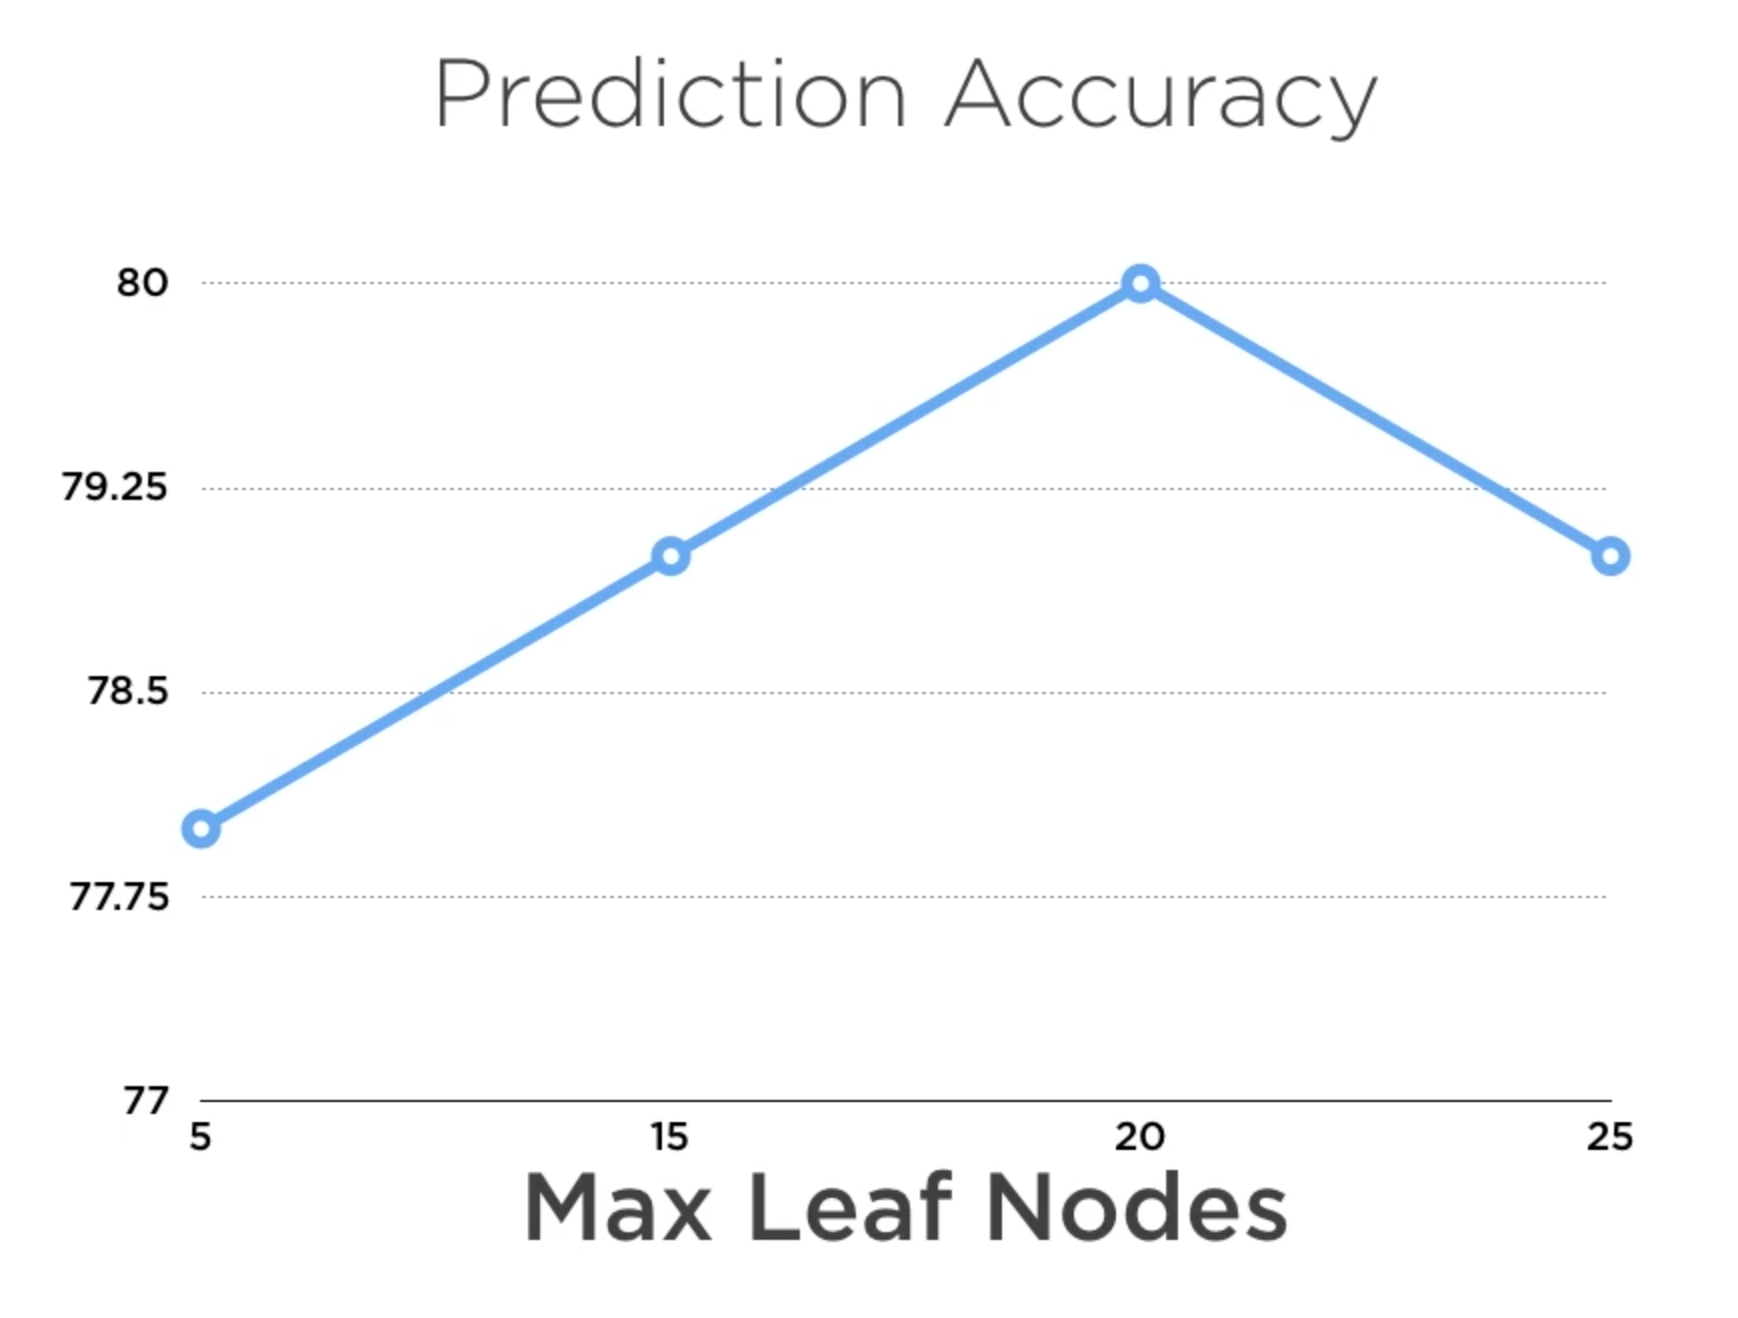

**Más allá de cierto umbral, la complejidad del modelo afecta negativamente el desempeño debido al sobreajuste**



### Profundizando en `min_samples_leaf` vs `min_samples_split`

Es común confundir estos dos parámetros, pero controlan momentos diferentes del crecimiento del árbol:

1.  **`min_samples_split`**: Es el requisito para **intentar** una división. Si un nodo tiene 10 muestras y el parámetro es 11, el nodo no se divide.
2.  **`min_samples_leaf`**: Es el requisito para **confirmar** una división. Una división solo se mantiene si *cada una* de las ramas resultantes tiene al menos el número de muestras definido en `min_samples_leaf`.

**Efecto en el modelo:**
*   **Valores bajos (ej. 1):** El modelo es más complejo, tiende al **sobreajuste** (overfitting) porque puede crear hojas para un solo dato específico.
*   **Valores altos (ej. 5, 10, o %):** El modelo es más simple y suave, mejora la **generalización** al evitar reglas demasiado específicas.

## ⚙️ Ajuste de hiperparámetros con `GridSearchCV`

`GridSearchCV` es una herramienta de `Scikit-learn` que automatiza la búsqueda de los **mejores hiperparámetros para un modelo**.

En lugar de probar combinaciones a mano, tú le pasas una 'rejilla' (un diccionario) con los valores que quieres probar. `GridSearchCV` hace lo siguiente:

1. **Combina**: Crea todas las combinaciones posibles de los parámetros que le diste.
2. **Entrena y Evalúa**: Para cada combinación, entrena el modelo usando **Validación Cruzada** (Cross-Validation). Esto asegura que la evaluación sea robusta.
3. **Selecciona:** Al terminar, identifica qué combinación obtuvo la mejor puntuación (según la métrica de `scoring` que elijas).



In [14]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 2, 3],
}

In [15]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,             # validación cruzada
    scoring="accuracy",
    n_jobs=-1         # usar todos los cores
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, None],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6, 8]},
             scoring='accuracy')

In [16]:
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best CV score: 0.9583333333333334


Además de `accuracy`, puedes pasar una variedad de métricas a `scoring` en `GridSearchCV` para evaluar el rendimiento de tu modelo, dependiendo del tipo de problema (clasificación, regresión, clustering, etc.).

Algunos valores comunes para problemas de **clasificación** incluyen:

- `precision`
- `recall`
- `f1` (o `f1_score`)

También puedes pasar funciones de scoring personalizadas o una lista/diccionario de métricas si quieres evaluar el modelo con varias métricas simultáneamente. Para una lista completa y más detalles, te recomiendo consultar la documentación oficial de `scikit-learn` sobre métricas de scoring

## 🚀 Evaluación final en el conjunto de prueba

In [18]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
# print(best_model.feature_importances_)

Test Accuracy: 1.0


### Matriz de Confusión para 3 clases
Como el dataset Iris tiene tres especies, la matriz de confusión nos permite ver exactamente dónde el modelo está confundiendo una especie con otra.

In [22]:
from sklearn.metrics import confusion_matrix

# Generar la matriz
cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

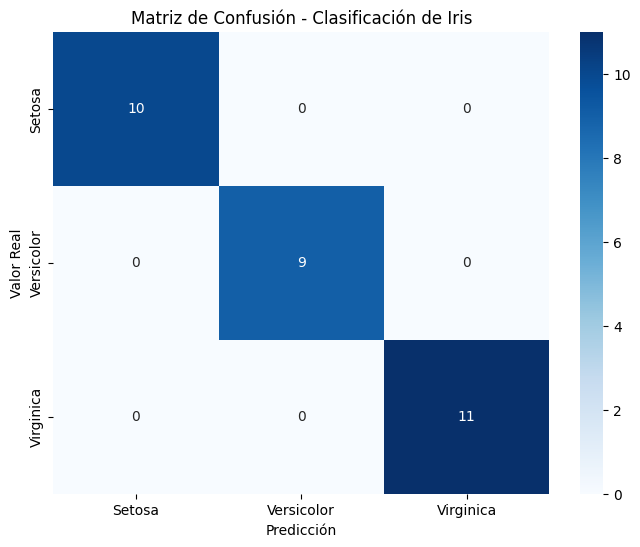

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Clasificación de Iris')
plt.show()

## 📌 Resumen de lo que se logra con este proceso

| Paso | Técnica                              | Objetivo                                          |
| ---- | ------------------------------------ | ------------------------------------------------- |
| 1    | Validación cruzada (cross_val_score) | Medir rendimiento del modelo base                 |
| 2    | GridSearchCV                         | Encontrar la mejor combinación de hiperparámetros |
| 3    | Evaluación final                     | Evaluar el mejor modelo sobre datos nunca vistos  |


## 💡 Recomendaciones para elegir valores en el `param_grid`

Para no perderte en miles de combinaciones, sigue esta estrategia:

*   **Regla de los bordes**: Si el `best_params_` te devuelve un valor que está en el límite de lo que propusiste (ej. `max_depth: 5` cuando tu lista terminaba en 5), significa que deberías expandir el rango en esa dirección (ej. probar 6, 7, 8).
*   **Escala Logarítmica**: Para parámetros que pueden variar mucho (como en otros modelos), prueba valores como `[0.1, 1, 10, 100]` en lugar de `[1, 2, 3, 4]`.
*   **Búsqueda Gruesa a Fina**: Primero haz una búsqueda con rangos amplios y saltos grandes. Una vez que encuentres la 'zona ganadora', haz una segunda búsqueda (`GridSearchCV`) más detallada solo en esa zona.

In [24]:
# Ejemplo de cómo 'refinar' la búsqueda basándonos en que los mejores resultados
# fueron: depth=5, split=2, leaf=3
param_grid_refined = {
    "criterion": ["entropy"], # Ya vimos que fue el mejor
    "max_depth": [4, 5, 6, 7], # Exploramos alrededor del 5
    "min_samples_split": [2, 3], # Bajamos el rango
    "min_samples_leaf": [3, 4, 5], # Probamos valores un poco más altos para ver si mejora estabilidad
}

Nueva rejilla sugerida para refinamiento:


{'criterion': ['entropy'],
 'max_depth': [4, 5, 6, 7],
 'min_samples_split': [2, 3],
 'min_samples_leaf': [3, 4, 5]}

# Referencias
- [Let’s Solve Overfitting! Quick Guide to Cost Complexity Pruning of Decision Trees](https://www.analyticsvidhya.com/blog/2020/10/cost-complexity-pruning-decision-trees/)
- [How to tune a Decision Tree?](https://towardsdatascience.com/how-to-tune-a-decision-tree-f03721801680)